#### Advanced Hyperparameter Search

Implement Bayesian optimisation (BO) for hyperparameter search. Use the idea of
‘scale and constrain’: fix a large model with base number of filters 32, 5 layers, and
best filter size from Task 2 then include a dropout layer before the final fully
connected layer and use BO to search over the regularisation parameter dropout
rate and L2 regularisation weighting (10 BO trials will be sufficient to complete
the task, 30 would be ideal if time permits).

In [1]:
import torch
from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,
import torch.optim as optim #Optimization module
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from torchaudio.transforms import FrequencyMasking, TimeMasking

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import numpy as np
import random
import time
import warnings
import os
from tqdm import tqdm

import pandas as pd
%matplotlib inline
warnings.filterwarnings("ignore")

In [2]:
import optuna
from torch.utils.data import Subset
import os

In [3]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

#### Training Configuration Parameters

In [4]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 64
    num_epochs: int = 40
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./speechImageData/speechImageData - Copy/"
    num_workers: int = 4 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cpu


#### Load Custom data available in Pytorch

In [5]:
train_root = os.path.join(train_config.data_root, "TrainData")
val_root = os.path.join(train_config.data_root, "ValData")

#### Data Preprocessing

In [6]:
mean = [0.4193]  #mean and std of this speech data
std = [0.3362]

img_size = (98, 50)

preprocess = transforms.Compose([
    transforms.Resize(img_size, antialias=True),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [7]:
common_transform = transforms.Compose([
    preprocess,
    transforms.Normalize(mean, std)
])

train_transforms = transforms.Compose([
    preprocess,
    transforms.RandomApply([
        TimeMasking(time_mask_param=10),
        FrequencyMasking(freq_mask_param=5)
    ],p=0.9),
    transforms.Normalize(mean,std)
])

#### Data Loader Preparation

In [8]:
train_data = datasets.ImageFolder(root= train_root, transform=train_transforms)
val_data = datasets.ImageFolder(root= val_root, transform=common_transform)

train_data.classes

['background',
 'down',
 'go',
 'left',
 'no',
 'off',
 'on',
 'right',
 'stop',
 'unknown',
 'up',
 'yes']

In [10]:
#Load only 50% of the train data
train_subset = Subset(train_data, range(len(train_data)//2))

train_loader = DataLoader(
    train_subset,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

In [9]:
#Load 100% of the train data

train_loader = DataLoader(
    train_data,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

#### Display Images from the Dataset

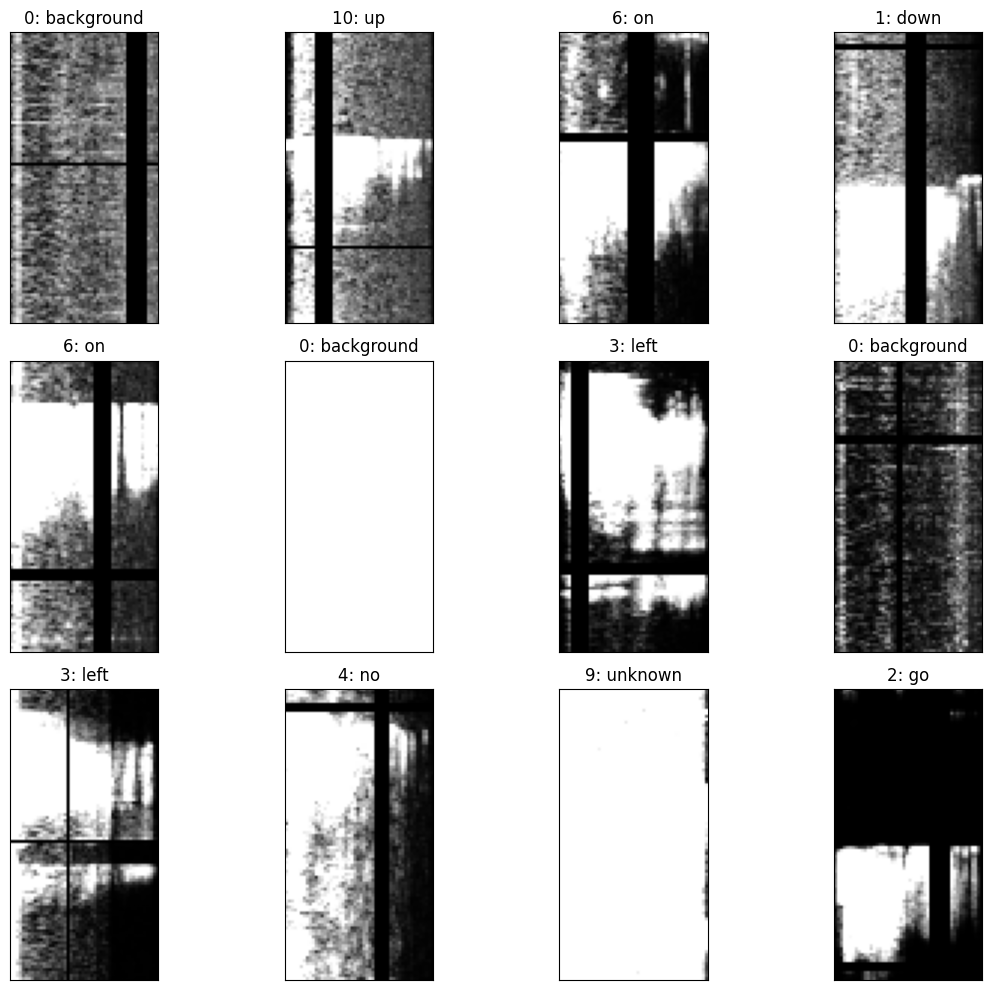

In [10]:
def visualize_images(trainloader, number_of_images=12):
    fig = plt.figure(figsize=(12,10))

    images, labels = next(iter(train_loader))

    num_rows = 3
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        image = image.squeeze()
        image = (image - image.min())/ (image.max() - image.min())
       
        ax.imshow(image, cmap='gray')

        ax.set_title(f"{label.item()}: {train_data.classes[label.item()]}")

    fig.tight_layout()

    plt.savefig("time_frequency_masking.pdf", dpi=600, bbox_inches="tight")
    plt.show()
visualize_images(train_loader)

#### CNN Model Implementation

In [14]:
class Model(nn.Module):
    def __init__(self, trial):
        super().__init__()

        self.base_num_filters = 32
        self.filter_size = 5 # Best parameter from the task 2
        self.num_layer = 5

        self.drop_out = trial.suggest_float("drop_out", 0.0, 0.7)

        layers = []

        width, height, c = 98, 50, 1

        filter_mul = 1

        for i in range(self.num_layer):
            layers.append(nn.Conv2d(in_channels=c, out_channels=self.base_num_filters * filter_mul, kernel_size=self.filter_size, padding="same"))
            layers.append(nn.BatchNorm2d(self.base_num_filters * filter_mul))
            layers.append(nn.ReLU())

            c = self.base_num_filters * filter_mul
            if ((i+1) % 2) == 0:
                layers.append(nn.MaxPool2d(kernel_size=(4,2), stride=(4,2)))
                filter_mul *= 2
                width = torch.floor_divide(width - 4, 4) + 1
                height = torch.floor_divide(height - 2, 2) + 1
                
        #-------Flatten------------
        layers.append(nn.Flatten())
        #------Classification------    
        layers.append(nn.Linear(in_features=width*height*c, out_features=256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=self.drop_out))
        layers.append(nn.Linear(in_features=256, out_features=12))
        
        self._model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self._model(x)

In [15]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.base_num_filters = 32
        self.filter_size = 5 # Best parameter from the task 2
        self.num_layer = 5

        self.drop_out = 0.22117067990033082

        layers = []

        width, height, c = 98, 50, 1

        filter_mul = 1

        for i in range(self.num_layer):
            layers.append(nn.Conv2d(in_channels=c, out_channels=self.base_num_filters * filter_mul, kernel_size=self.filter_size, padding="same"))
            layers.append(nn.BatchNorm2d(self.base_num_filters * filter_mul))
            layers.append(nn.ReLU())

            c = self.base_num_filters * filter_mul
            if ((i+1) % 2) == 0:
                layers.append(nn.MaxPool2d(kernel_size=(4,2), stride=(4,2)))
                filter_mul *= 2
                width = torch.floor_divide(width - 4, 4) + 1
                height = torch.floor_divide(height - 2, 2) + 1
                
        #-------Flatten------------
        layers.append(nn.Flatten())
        #------Classification------    
        layers.append(nn.Linear(in_features=width*height*c, out_features=256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=self.drop_out))
        layers.append(nn.Linear(in_features=256, out_features=12))
        
        self._model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self._model(x)

#### Model Training and Evaluation

In [16]:
def train(model, train_loader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = F.cross_entropy(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [17]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = F.cross_entropy(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [27]:
def objective(trial):
    
    model = Model(trial)

    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e0, log=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay=weight_decay)

    logdir = "runs/80epoch-3.3M_param_dropout"

    writer = SummaryWriter(logdir)

    dummy_input = (1,1,98,50)

    print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))
    
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    print(trial.params)
    
    model_name = f"Model_DO{trial.params['drop_out']}_WD{trial.params['weight_decay']}"

     # Resume if checkpoint exists
    start_epoch = 0
    if os.path.exists(f'Checkpoints_task_4/{model_name}.pt'):
        checkpoint = torch.load(f'Checkpoints_task_4/{model_name}.pt')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
    
    for epoch in range(start_epoch, train_config.num_epochs):
        if epoch % 5 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }
            torch.save(checkpoint, f'Checkpoint_task_4/{model_name}.pt')
        train_loss, train_accuracy = train(model,train_loader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        trial.report(val_accuracy, epoch)
        
        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)


    return max(val_accuracies)

In [28]:
# Create study

# train_config.num_epochs = 5

study = optuna.create_study(direction="maximize", sampler= optuna.samplers.TPESampler())

# Optimize
study.optimize(objective, n_trials=30)

[I 2026-03-20 14:52:12,025] A new study created in memory with name: no-name-5d1d8adb-91dc-4176-b0b0-81b1142460e1


Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 12]                   --
├─Sequential (_model)                    [1, 12]                   --
│    └─Conv2d (0)                        [1, 32, 98, 50]           832
│    └─BatchNorm2d (1)                   [1, 32, 98, 50]           64
│    └─ReLU (2)                          [1, 32, 98, 50]           --
│    └─Conv2d (3)                        [1, 32, 98, 50]           25,632
│    └─BatchNorm2d (4)                   [1, 32, 98, 50]           64
│    └─ReLU (5)                          [1, 32, 98, 50]           --
│    └─MaxPool2d (6)                     [1, 32, 24, 25]           --
│    └─Conv2d (7)                        [1, 64, 24, 25]           51,264
│    └─BatchNorm2d (8)                   [1, 64, 24, 25]           128
│    └─ReLU (9)                          [1, 64, 24, 25]           --
│    └─Conv2d (10)                       [1, 64, 24, 25]           102,464


Validation: 100%|███████████████████████████████| 10/10 [00:03<00:00,  3.00it/s]


Epoch 1 - Train loss: 1.699693650007248 Train accuracy: 37.7 %%% Val loss: 2.9028734087944033 Val accuracy: 5.123825789923143


Validation: 100%|███████████████████████████████| 10/10 [00:03<00:00,  3.00it/s]


...

Epoch 38 - Train loss: 0.06483881874009967 Train accuracy: 98.6 %%% Val loss: 6.519169569015503 Val accuracy: 35.18360375747225


Validation: 100%|███████████████████████████████| 10/10 [00:05<00:00,  1.78it/s]


Epoch 39 - Train loss: 0.0698535512201488 Train accuracy: 98.1 %%% Val loss: 6.211138069629669 Val accuracy: 35.098206660973524


Validation: 100%|███████████████████████████████| 10/10 [00:05<00:00,  1.79it/s]
[I 2026-03-20 20:44:43,142] Trial 29 finished with value: 36.46456020495303 and parameters: {'drop_out': 0.45302209513509045, 'weight_decay': 2.5106839824263094e-05}. Best is trial 12 with value: 38.087105038428696.


Epoch 40 - Train loss: 0.05775895714759827 Train accuracy: 98.4 %%% Val loss: 6.43269681930542 Val accuracy: 35.952177625960715


In [30]:
study.best_params

{'drop_out': 0.22117067990033082, 'weight_decay': 0.0004725992033945145}

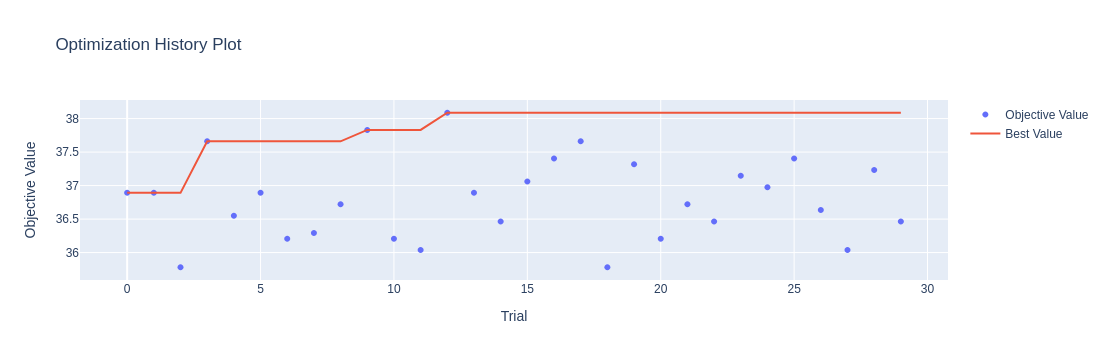

In [35]:
optuna.visualization.plot_optimization_history(study)

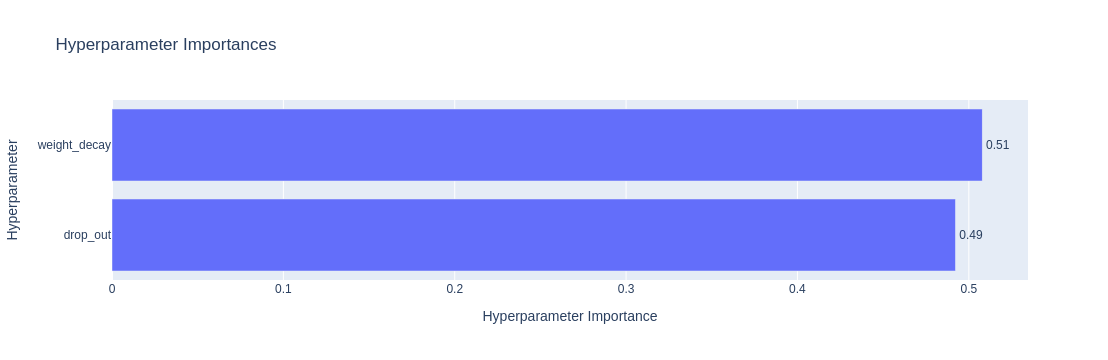

In [32]:
optuna.visualization.plot_param_importances(study)

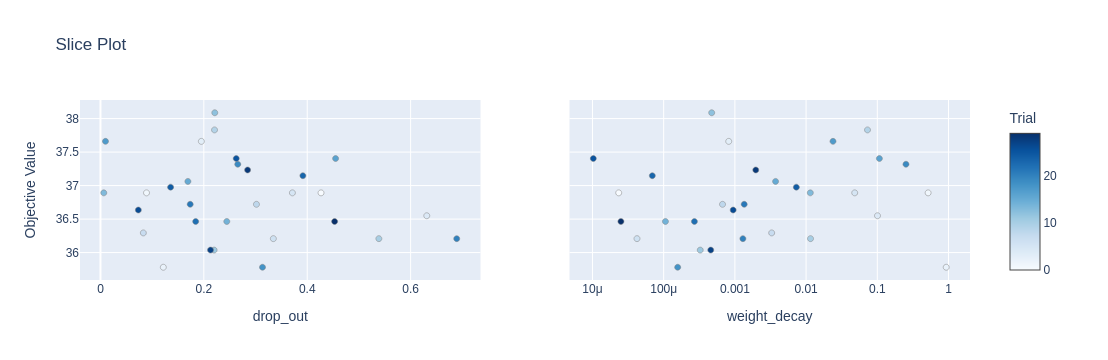

In [33]:
optuna.visualization.plot_slice(study)

In [18]:
model = Model()

optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay= 0.0004725992033945145) #best parameter

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,1,98,50)

print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))

Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 12]                   --
├─Sequential (_model)                    [1, 12]                   --
│    └─Conv2d (0)                        [1, 32, 98, 50]           832
│    └─BatchNorm2d (1)                   [1, 32, 98, 50]           64
│    └─ReLU (2)                          [1, 32, 98, 50]           --
│    └─Conv2d (3)                        [1, 32, 98, 50]           25,632
│    └─BatchNorm2d (4)                   [1, 32, 98, 50]           64
│    └─ReLU (5)                          [1, 32, 98, 50]           --
│    └─MaxPool2d (6)                     [1, 32, 24, 25]           --
│    └─Conv2d (7)                        [1, 64, 24, 25]           51,264
│    └─BatchNorm2d (8)                   [1, 64, 24, 25]           128
│    └─ReLU (9)                          [1, 64, 24, 25]           --
│    └─Conv2d (10)                       [1, 64, 24, 25]           102,464


In [19]:
def main(model, trainloader, val_loader, DEVICE='cpu'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        train_loss, train_accuracy = train(model,trainloader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best_task_4_param.pt")
            

    return train_losses, val_losses, train_accuracies, val_accuracies

In [20]:
train_losses, val_losses, train_accuracies, val_accuracies = main(model, train_loader, val_loader, 'cpu')

Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.61it/s]


Epoch 1 - Train loss: 2.1712177097797394 Train accuracy: 25.28735632183908 %%% Val loss: 2.5994060933589935 Val accuracy: 13.748932536293767
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.64it/s]


Epoch 2 - Train loss: 1.7672923058271408 Train accuracy: 42.728635682158924 %%% Val loss: 1.8324652400455976 Val accuracy: 39.36806148590948
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.75it/s]


...

Epoch 38 - Train loss: 0.05460305034648627 Train accuracy: 98.80059970014993 %%% Val loss: 1.1294315374015194 Val accuracy: 73.9538855678907


Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.45it/s]


Epoch 39 - Train loss: 0.04526117755449377 Train accuracy: 99.2503748125937 %%% Val loss: 1.0887205868371224 Val accuracy: 74.12467976088813


Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.31it/s]

Epoch 40 - Train loss: 0.0384892460424453 Train accuracy: 99.40029985007496 %%% Val loss: 1.1755351155604188 Val accuracy: 73.0999146029035


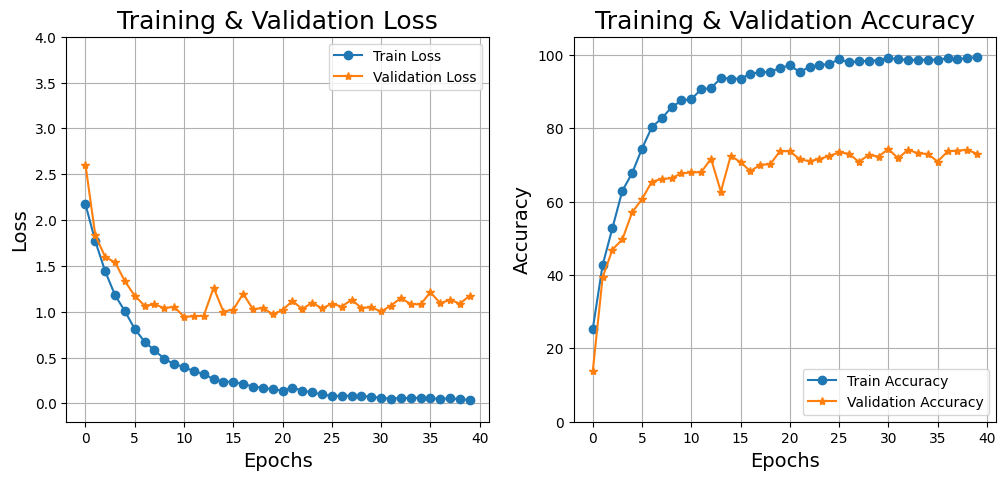

In [21]:
FONT_SIZE = 14
TITLE_SIZE = 18
X_LABEL_SIZE = 14
Y_LABEL_SIZE = 14
LEGEND_SIZE = 10

PLOT_FILE = "task_4_with_best_param.pdf"

plt.figure(figsize=[12,5])

plt.subplot(1,2,1)
plt.plot(range(0,len(train_losses)), train_losses, label="Train Loss", marker='o')
plt.plot(range(0,len(train_losses)), val_losses, label="Validation Loss", marker='*')

plt.ylim([-0.2,4])
plt.xlabel("Epochs", fontsize=X_LABEL_SIZE)
plt.ylabel("Loss", fontsize=Y_LABEL_SIZE)
plt.title("Training & Validation Loss", fontsize=TITLE_SIZE)
plt.grid()

plt.legend()

plt.subplot(1,2,2)
plt.plot(range(0,len(train_accuracies)), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(0,len(val_accuracies)), val_accuracies, label="Validation Accuracy", marker='*')

plt.ylim([0,105])
plt.xlabel("Epochs", fontsize=X_LABEL_SIZE)
plt.ylabel("Accuracy", fontsize=Y_LABEL_SIZE)
plt.title("Training & Validation Accuracy", fontsize=TITLE_SIZE)

plt.legend()

plt.grid()

plt.savefig(PLOT_FILE, dpi=600, bbox_inches="tight")